This notebook was built to conduct a preliminary screening phase on the monk datasets. The goal was to get a sense of the hyperparameters impact.
Note that this version of the notebook does not contain the output plots, as they were removed to reduce the size of the delivery.
You can find the executed version [here](https://github.com/leonardocrociani/Neural-Network/blob/main/src/screening_cup.ipynb).
You can also open the code in colab with this badge:

In [4]:
from sklearn.model_selection import train_test_split
from lib.data_loader import get_cup_dataset
from lib.neural_network import NeuralNetwork
import numpy as np

X_dev, y_dev, _,_ = get_cup_dataset()
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_dev, y_dev, test_size=0.2, random_state=42
)

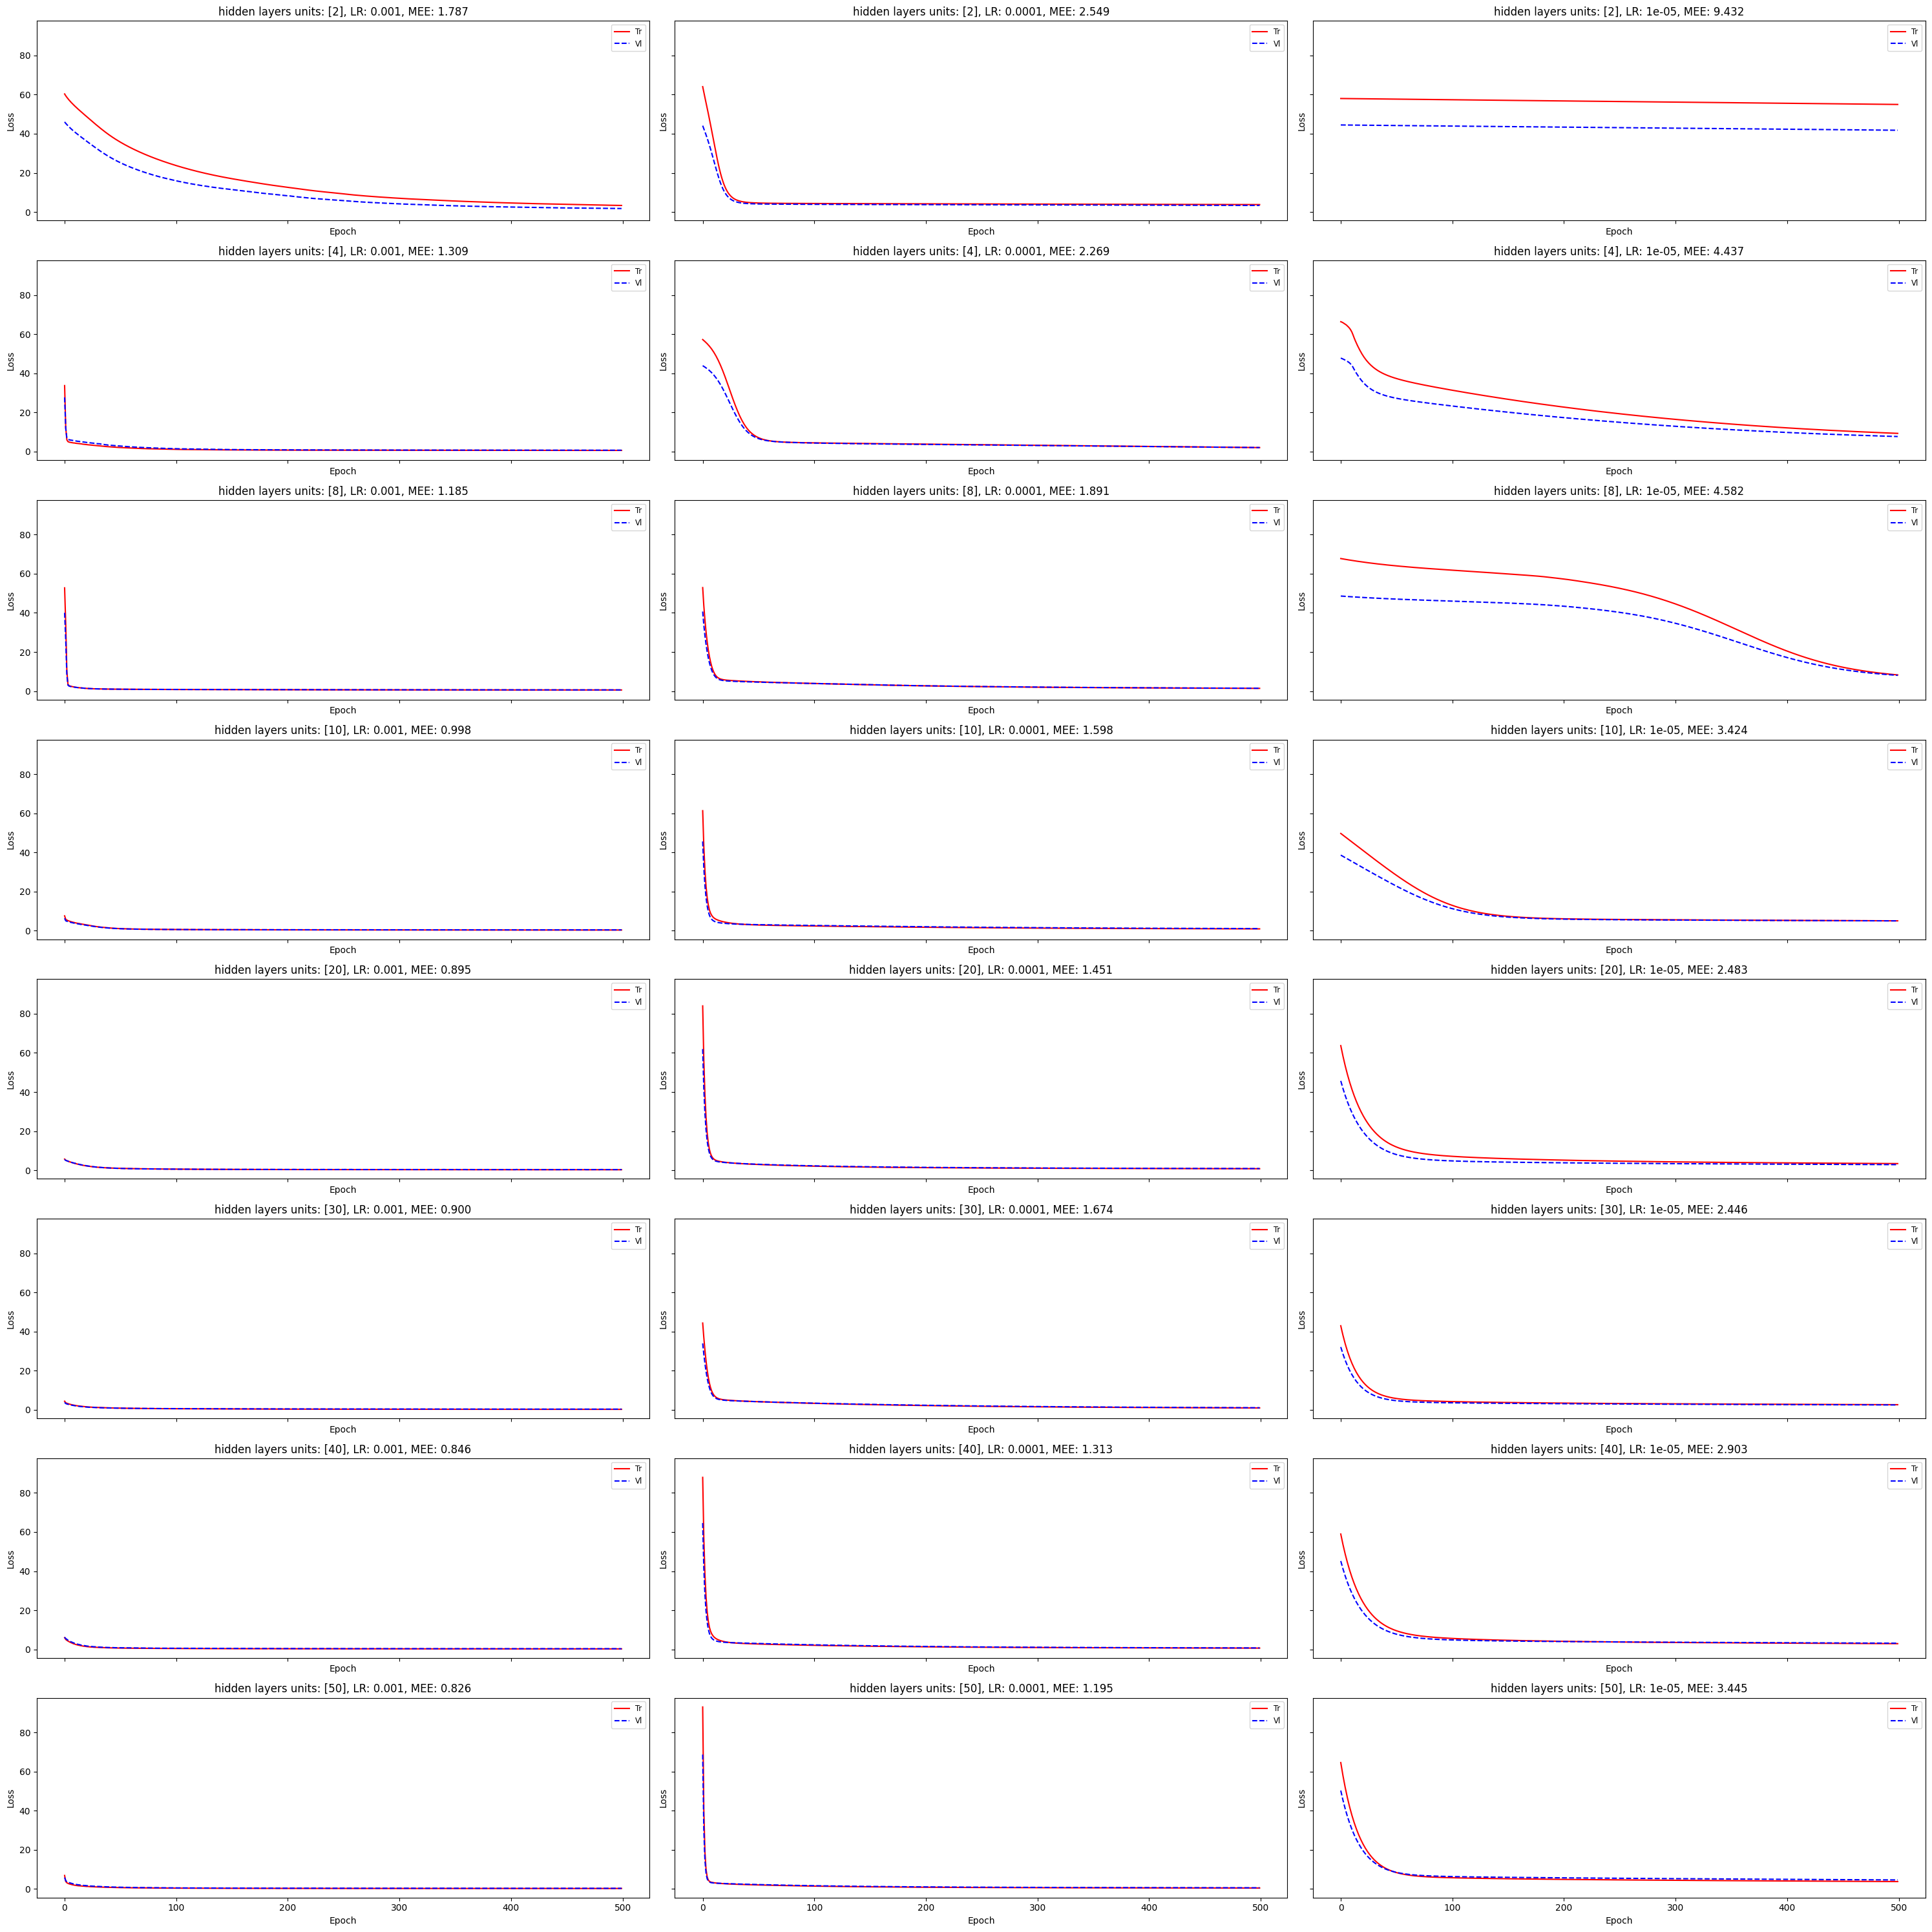

In [5]:
import matplotlib.pyplot as plt

layers_combo = [
    [2],
    [4],
    [8],
    [10], 
    [20], 
    [30], 
    [40],
    [50]
]

lrs = [
   0.001, 0.0001, 0.00001
]

fig, axs = plt.subplots(len(layers_combo), len(lrs), figsize=(30, 30),
                        sharex=True, sharey=True)

for i, lcombo in enumerate(layers_combo):
    for j, lr in enumerate(lrs):
        nn = NeuralNetwork(
            layers=[12] + lcombo + [3],
            learning_rate=lr,
            lr_decay_type='none', 
            error_function_name="mse",
            activation_function_names=["relu", "linear"],
            reg_type='l2',
            lambda_reg=.001,
            task="regression",
            weight_init="he",
            momentum_type="none"
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=32,
            verbose=False,
            validation_data=(X_val_split, y_val_split),
        )
        
        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
        ax.set_title(f"hidden layers units: {lcombo}, LR: {lr}, MEE: {mee:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()


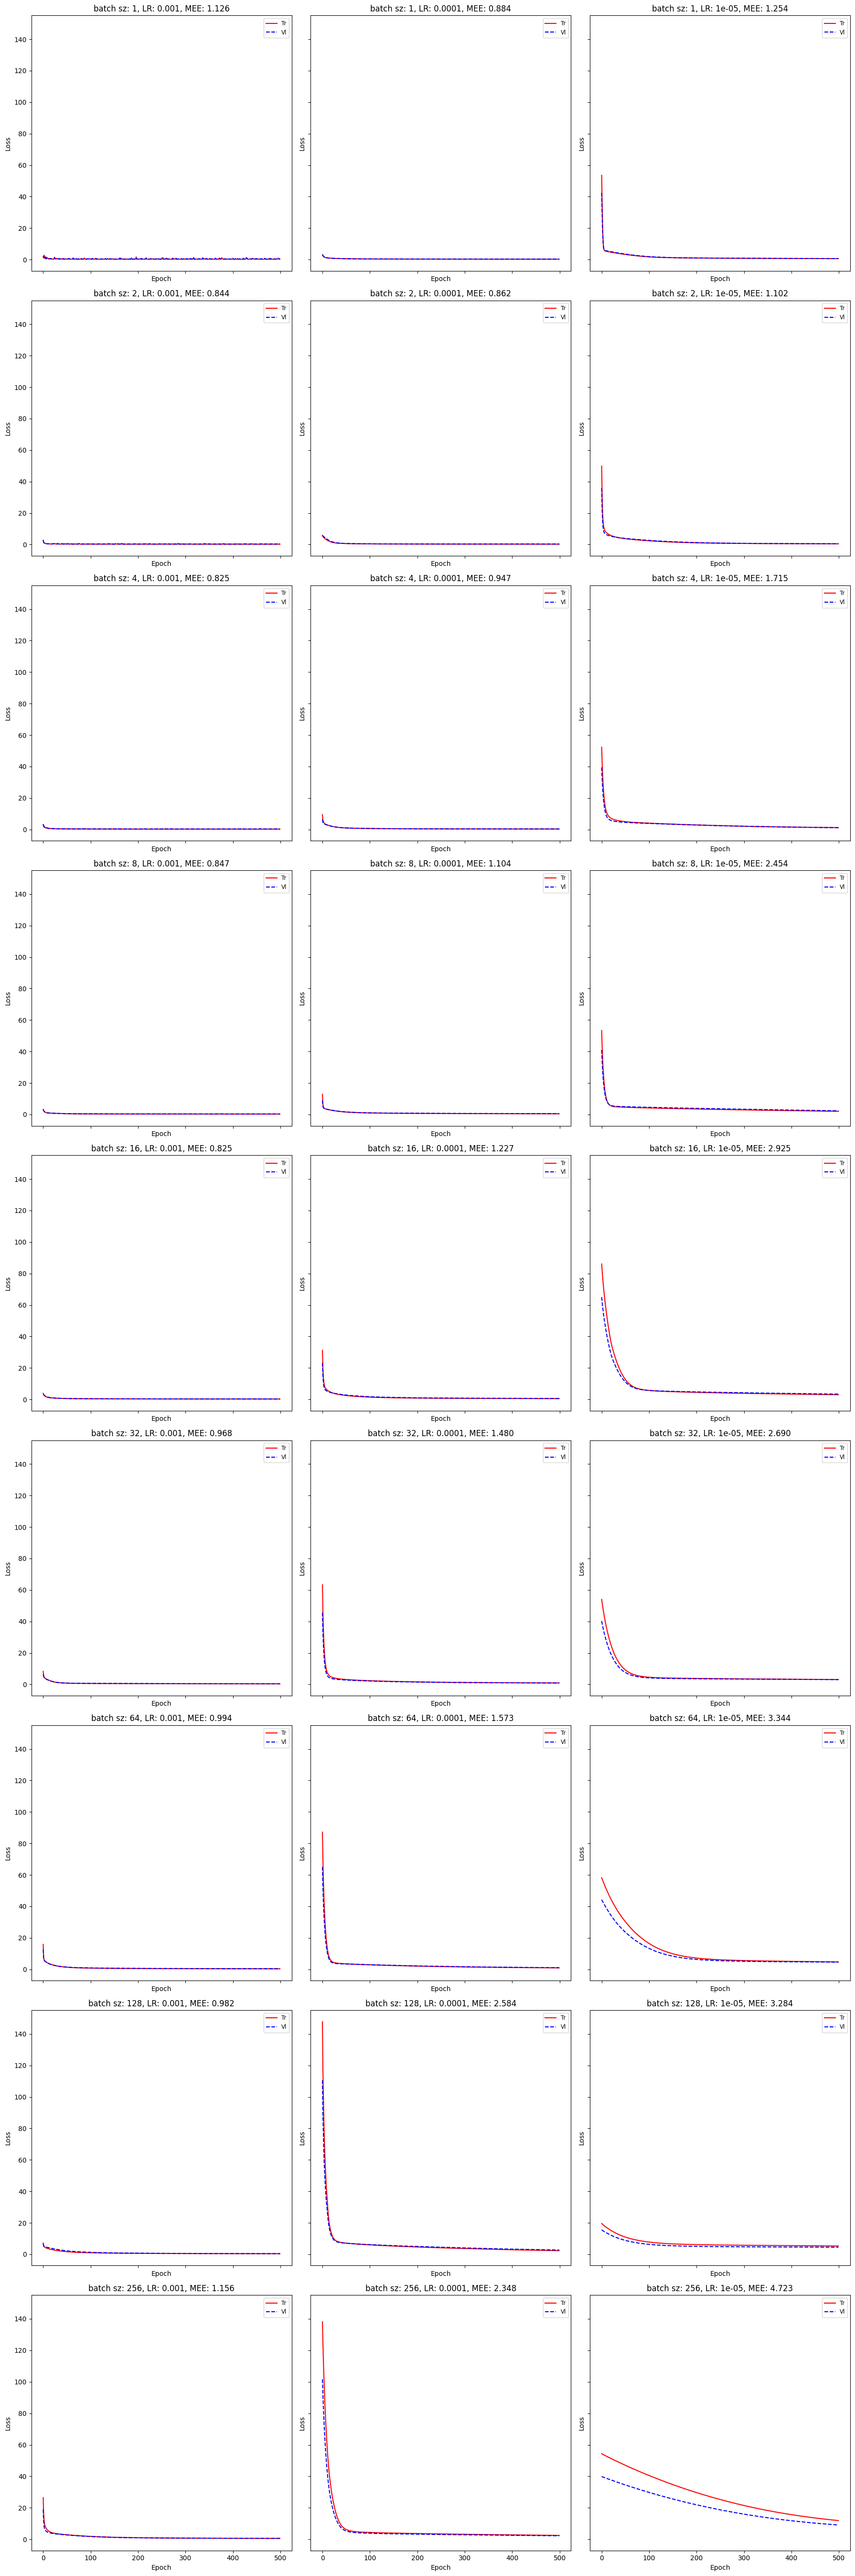

In [6]:
import matplotlib.pyplot as plt

batch_sizes = [
   1, 2, 4, 8, 16, 32, 64, 128, 256
]

lrs = [
   0.001, 0.0001, 0.00001
]

fig, axs = plt.subplots(len(batch_sizes), len(lrs), figsize=(6*len(lrs), 6*len(batch_sizes)),
                        sharex=True, sharey=True)

for i, bs in enumerate(batch_sizes):
    for j, lr in enumerate(lrs):
        nn = NeuralNetwork(
            layers=[12, 20, 3],
            learning_rate=lr,
            lr_decay_type='none', 
            error_function_name="mse",
            activation_function_names=["relu", "linear"],
            reg_type='l2',
            lambda_reg=.001,
            task="regression",
            weight_init="he",
            momentum_type="none"
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=bs,
            verbose=False,
            validation_data=(X_val_split, y_val_split),
        )
        
        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
        ax.set_title(f"batch sz: {bs}, LR: {lr}, MEE: {mee:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

In [7]:
# 16 seems to work best, but let's do a test:


batch_sizes = [
   1, 2, 4, 8, 16, 32, 64, 128, 256
]

lrs = [
   0.001, 0.0001, 0.00001
]

from tqdm import tqdm
SIMULATIONS = 10
results = []

for _ in tqdm(range(SIMULATIONS)):
    
    data = {}
    
    for i, bs in enumerate(batch_sizes):
        for j, lr in enumerate(lrs):
            nn = NeuralNetwork(
                layers=[12, 20, 3],
                learning_rate=lr,
                lr_decay_type='none', 
                error_function_name="mse",
                activation_function_names=["relu", "linear"],
                reg_type='l2',
                lambda_reg=.001,
                task="regression",
                weight_init="he",
                momentum_type="none"
            )

            nn.train(
                X_train_split,
                y_train_split,
                epochs=500,
                batch_size=bs,
                verbose=False,
                validation_data=(X_val_split, y_val_split),
            )
            
            mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
            data[(bs, lr)] = mee
            
    results.append(data)

100%|██████████| 10/10 [02:44<00:00, 16.46s/it]


In [8]:
reverse_index = {}
for data in results:
    for k in data:
        if k not in reverse_index:
            reverse_index[k] = []
        reverse_index[k].append(data[k])
        
for k in reverse_index:
    reverse_index[k] = {
        'mean' : np.mean(reverse_index[k]), 
        'std' : np.std(reverse_index[k])
    }
    
sorted_mean = sorted(reverse_index.items(), key=lambda x: x[1]['mean'])
sorted_std = sorted(reverse_index.items(), key=lambda x: x[1]['std'])

scores = []

for idx, el in enumerate(sorted_mean):
    index_in_std = sorted_std.index(el)
    scores.append((el, idx + index_in_std, el[1]['mean'], el[1]['std']))
    
sorted(scores, key=lambda x: x[1])

[(((4, 0.001),
   {'mean': np.float64(0.8597710148427431),
    'std': np.float64(0.04733428757527903)}),
  8,
  np.float64(0.8597710148427431),
  np.float64(0.04733428757527903)),
 (((1, 0.0001),
   {'mean': np.float64(0.8745574653223531),
    'std': np.float64(0.04678152225990026)}),
  8,
  np.float64(0.8745574653223531),
  np.float64(0.04678152225990026)),
 (((8, 0.001),
   {'mean': np.float64(0.8757155853097476),
    'std': np.float64(0.04149412387176416)}),
  8,
  np.float64(0.8757155853097476),
  np.float64(0.04149412387176416)),
 (((16, 0.001),
   {'mean': np.float64(0.890565885743056),
    'std': np.float64(0.037602400109744305)}),
  8,
  np.float64(0.890565885743056),
  np.float64(0.037602400109744305)),
 (((2, 0.0001),
   {'mean': np.float64(0.9162760316129376),
    'std': np.float64(0.03580941043669323)}),
  8,
  np.float64(0.9162760316129376),
  np.float64(0.03580941043669323)),
 (((64, 0.001),
   {'mean': np.float64(0.962736794538313),
    'std': np.float64(0.03318791488729

np.float64(0.8549603559581278)

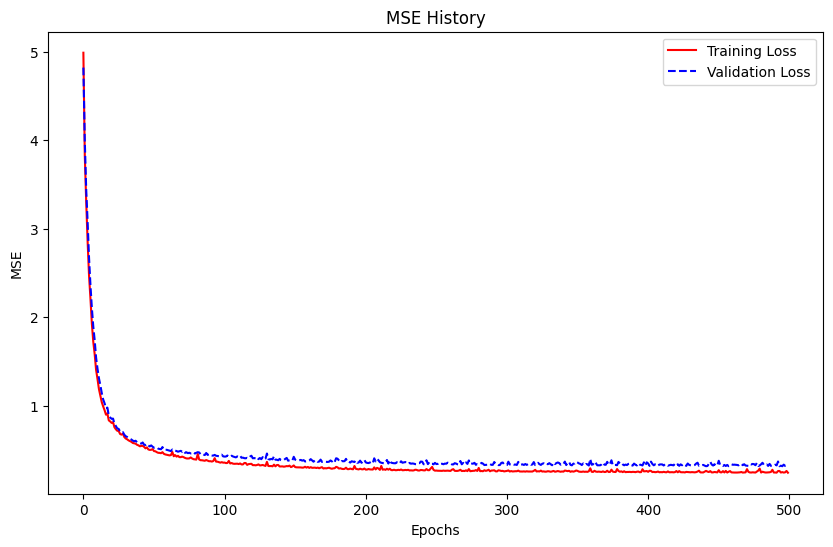

In [9]:
import matplotlib.pyplot as plt

nn = NeuralNetwork(
    layers=[12, 20, 3],
    learning_rate=0.001,
    lr_decay_type="none",
    error_function_name="mse",
    activation_function_names=["relu", "linear"],
    reg_type="l2",
    lambda_reg=0.001,
    task="regression",
    weight_init="he",
    momentum_type="none",
)

nn.train(
    X_train_split,
    y_train_split,
    epochs=500,
    batch_size=16,
    verbose=False,
    validation_data=(X_val_split, y_val_split),
)

nn.plot_learning_curve()
mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
mee

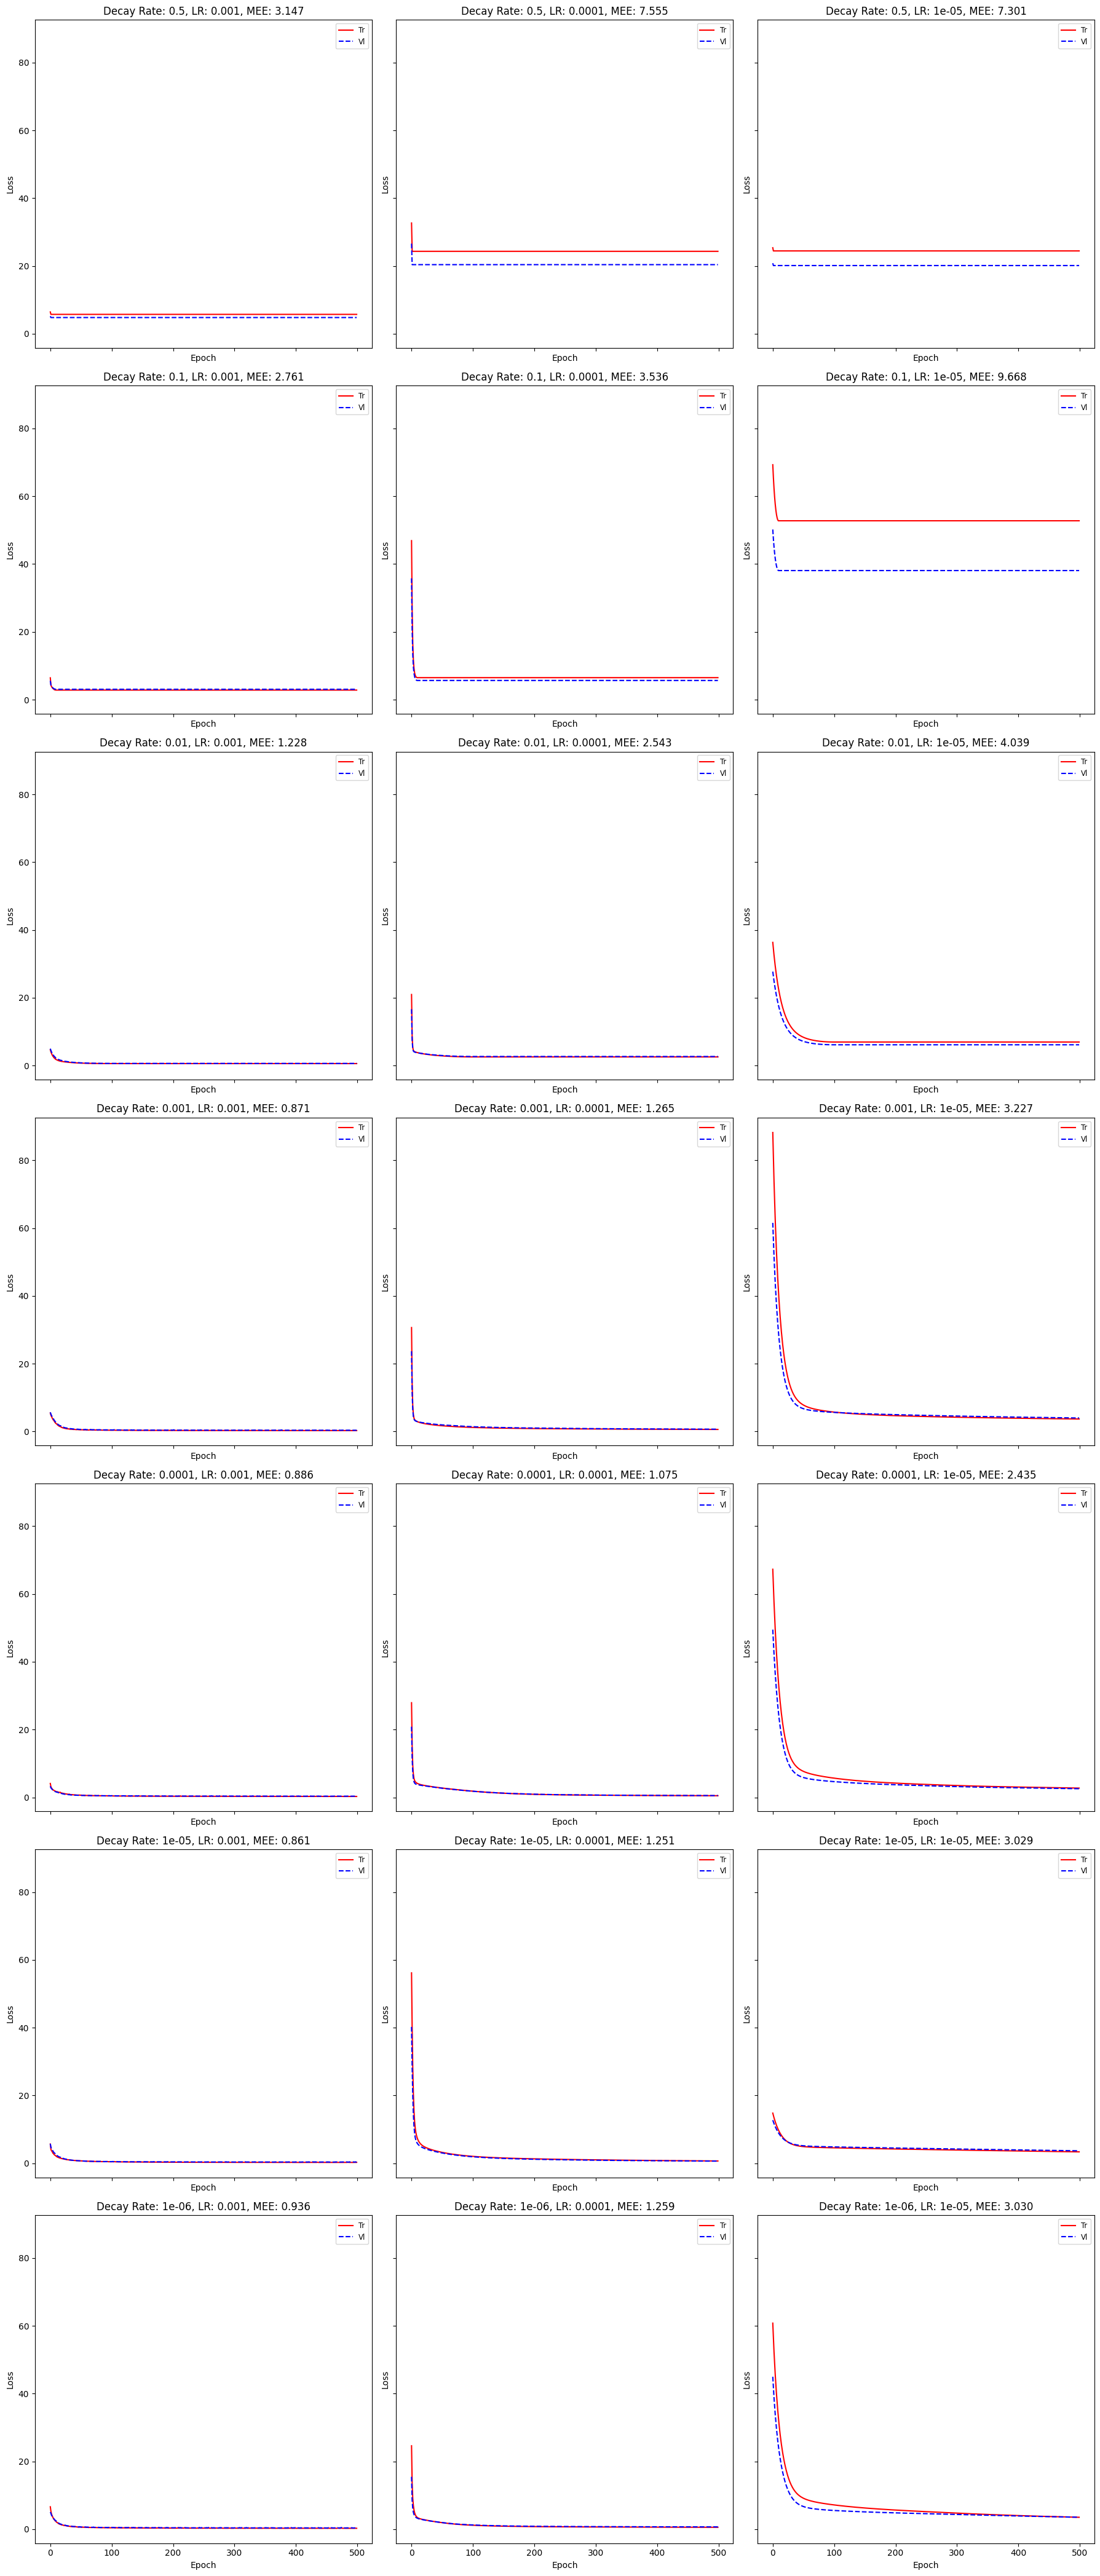

In [10]:
import matplotlib.pyplot as plt

decay_rates = [
    0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001
]

lrs = [
   0.001, 0.0001, 0.00001
]

fig, axs = plt.subplots(len(decay_rates), len(lrs), figsize=(6*len(lrs), 6*len(decay_rates)),
                        sharex=True, sharey=True)

for i, dr in enumerate(decay_rates):
    for j, lr in enumerate(lrs):
        nn = NeuralNetwork(
            layers=[12, 20, 3],
            learning_rate=lr,
            decay_rate=dr, 
            lr_decay_type='linear', 
            error_function_name="mse",
            activation_function_names=["relu", "linear"],
            reg_type='l2',
            lambda_reg=.001,
            task="regression",
            weight_init="he",
            momentum_type="none"
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=16,
            verbose=False,
            validation_data=(X_val_split, y_val_split),
        )
        
        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
        ax.set_title(f"Decay Rate: {dr}, LR: {lr}, MEE: {mee:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

In [11]:
decay_rates = [
    0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001
]

lrs = [
   0.001, 0.0001, 0.00001
]

from tqdm import tqdm
SIMULATIONS = 10
results = []

for _ in tqdm(range(SIMULATIONS)):
    
    data = {}
    
    for i, dr in enumerate(decay_rates):
        for j, lr in enumerate(lrs):
            nn = NeuralNetwork(
                layers=[12, 20, 3],
                decay_rate=dr,
                learning_rate=lr,
                lr_decay_type='linear', 
                error_function_name="mse",
                activation_function_names=["relu", "linear"],
                reg_type='l2',
                lambda_reg=.001,
                task="regression",
                weight_init="he",
                momentum_type="none"
            )

            nn.train(
                X_train_split,
                y_train_split,
                epochs=500,
                batch_size=16,
                verbose=False,
                validation_data=(X_val_split, y_val_split),
            )
            
            mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
            data[(dr, lr)] = mee
            
    results.append(data)

100%|██████████| 10/10 [00:53<00:00,  5.35s/it]


In [12]:
reverse_index = {}
for data in results:
    for k in data:
        if k not in reverse_index:
            reverse_index[k] = []
        reverse_index[k].append(data[k])
        
for k in reverse_index:
    reverse_index[k] = {
        'mean' : np.mean(reverse_index[k]), 
        'std' : np.std(reverse_index[k])
    }
    
# sorted(reverse_index.items(), key=lambda x: x[1]['mean'])
sorted(reverse_index.items(), key=lambda x: x[1]['std']) 

# dr 1e-05 with lr 0.001 seems to work best.

[((0.0001, 0.001),
  {'mean': np.float64(0.8770743179812843),
   'std': np.float64(0.02565687011334707)}),
 ((1e-06, 0.001),
  {'mean': np.float64(0.8910906511905955),
   'std': np.float64(0.026298229900233772)}),
 ((1e-05, 0.001),
  {'mean': np.float64(0.9002033799301417),
   'std': np.float64(0.035982812135773916)}),
 ((0.001, 0.001),
  {'mean': np.float64(0.900387523914423),
   'std': np.float64(0.039032754933402414)}),
 ((1e-05, 0.0001),
  {'mean': np.float64(1.2046178810807946),
   'std': np.float64(0.05712963575021269)}),
 ((0.01, 0.001),
  {'mean': np.float64(1.2135780116083532),
   'std': np.float64(0.058881730415231245)}),
 ((0.0001, 0.0001),
  {'mean': np.float64(1.2192741625054921),
   'std': np.float64(0.0858684850481772)}),
 ((1e-06, 0.0001),
  {'mean': np.float64(1.2247992762498565),
   'std': np.float64(0.11446424283095297)}),
 ((0.001, 0.0001),
  {'mean': np.float64(1.327250799960701),
   'std': np.float64(0.17070555950897595)}),
 ((0.01, 0.0001),
  {'mean': np.float64(

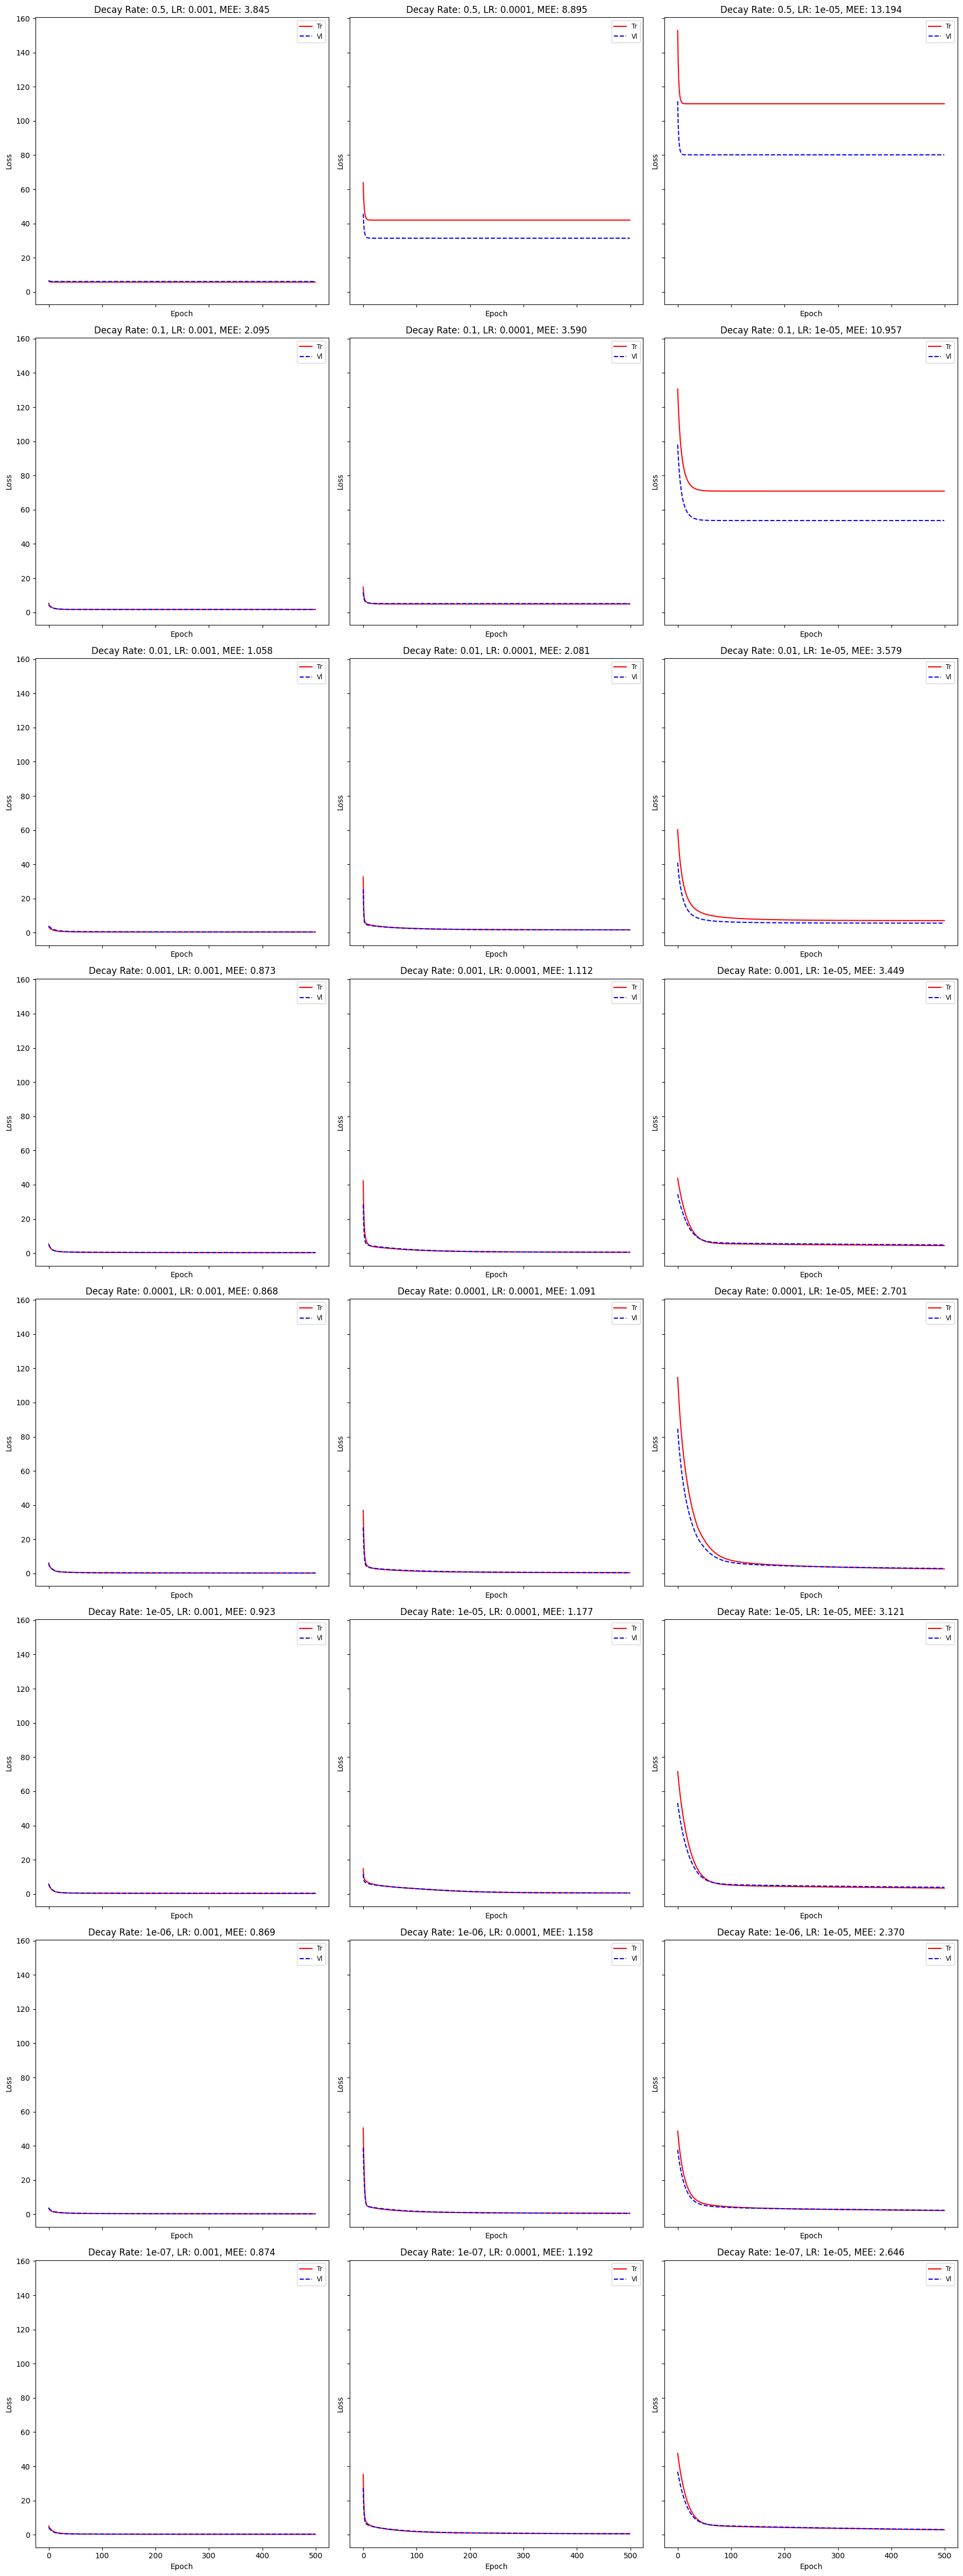

In [13]:
import matplotlib.pyplot as plt

decay_rates = [
    0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001
]

lrs = [
   0.001, 0.0001, 0.00001
]

fig, axs = plt.subplots(len(decay_rates), len(lrs), figsize=(6*len(lrs), 6*len(decay_rates)),
                        sharex=True, sharey=True)

for i, dr in enumerate(decay_rates):
    for j, lr in enumerate(lrs):
        nn = NeuralNetwork(
            layers=[12, 20, 3],
            learning_rate=lr,
            decay_rate=dr, 
            lr_decay_type='exponential', 
            error_function_name="mse",
            activation_function_names=["relu", "linear"],
            reg_type='l2',
            lambda_reg=.001,
            task="regression",
            weight_init="he",
            momentum_type="none"
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=16,
            verbose=False,
            validation_data=(X_val_split, y_val_split),
        )
        
        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
        ax.set_title(f"Decay Rate: {dr}, LR: {lr}, MEE: {mee:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

In [14]:
decay_rates = [
    0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001
]

lrs = [
   0.001, 0.0001, 0.00001
]

from tqdm import tqdm
SIMULATIONS = 10
results = []

for _ in tqdm(range(SIMULATIONS)):
    
    data = {}
    
    for i, dr in enumerate(decay_rates):
        for j, lr in enumerate(lrs):
            nn = NeuralNetwork(
                layers=[12, 20, 3],
                decay_rate=dr,
                learning_rate=lr,
                lr_decay_type='exponential', 
                error_function_name="mse",
                activation_function_names=["relu", "linear"],
                reg_type='l2',
                lambda_reg=.001,
                task="regression",
                weight_init="he",
                momentum_type="none"
            )

            nn.train(
                X_train_split,
                y_train_split,
                epochs=500,
                batch_size=16,
                verbose=False,
                validation_data=(X_val_split, y_val_split),
            )
            
            mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
            data[(dr, lr)] = mee
            
    results.append(data)

100%|██████████| 10/10 [00:57<00:00,  5.78s/it]


In [15]:
reverse_index = {}
for data in results:
    for k in data:
        if k not in reverse_index:
            reverse_index[k] = []
        reverse_index[k].append(data[k])
        
for k in reverse_index:
    reverse_index[k] = {
        'mean' : np.mean(reverse_index[k]), 
        'std' : np.std(reverse_index[k])
    }
    
sorted(reverse_index.items(), key=lambda x: x[1]['mean'])
sorted(reverse_index.items(), key=lambda x: x[1]['std']) # anche con exponential, 1e-05 è il migliore. tra un tipo di decay e l'altro, meglio  0.857+-0.01 or 0.8369+-0.03? => 0.857+-0.01 è meglio o peggio? => 0.857+-0.01 è meglio, perchè ha una varianza minore => linear

[((1e-06, 0.001),
  {'mean': np.float64(0.8690515237746117),
   'std': np.float64(0.027679242852998068)}),
 ((0.001, 0.001),
  {'mean': np.float64(0.8905932589551867),
   'std': np.float64(0.03241634569109536)}),
 ((1e-05, 0.001),
  {'mean': np.float64(0.8854938623283394),
   'std': np.float64(0.03252119414166477)}),
 ((1e-07, 0.001),
  {'mean': np.float64(0.8861797944960813),
   'std': np.float64(0.03514163500570545)}),
 ((0.0001, 0.001),
  {'mean': np.float64(0.9020760843443949),
   'std': np.float64(0.03806580409990216)}),
 ((0.01, 0.001),
  {'mean': np.float64(1.0156773734900908),
   'std': np.float64(0.04349705101230448)}),
 ((1e-05, 0.0001),
  {'mean': np.float64(1.1566407130792664),
   'std': np.float64(0.09377930535101035)}),
 ((1e-07, 0.0001),
  {'mean': np.float64(1.1611494163686389),
   'std': np.float64(0.09633568532465539)}),
 ((0.001, 0.0001),
  {'mean': np.float64(1.310590077532995),
   'std': np.float64(0.10265294188146303)}),
 ((0.0001, 0.0001),
  {'mean': np.float64(1

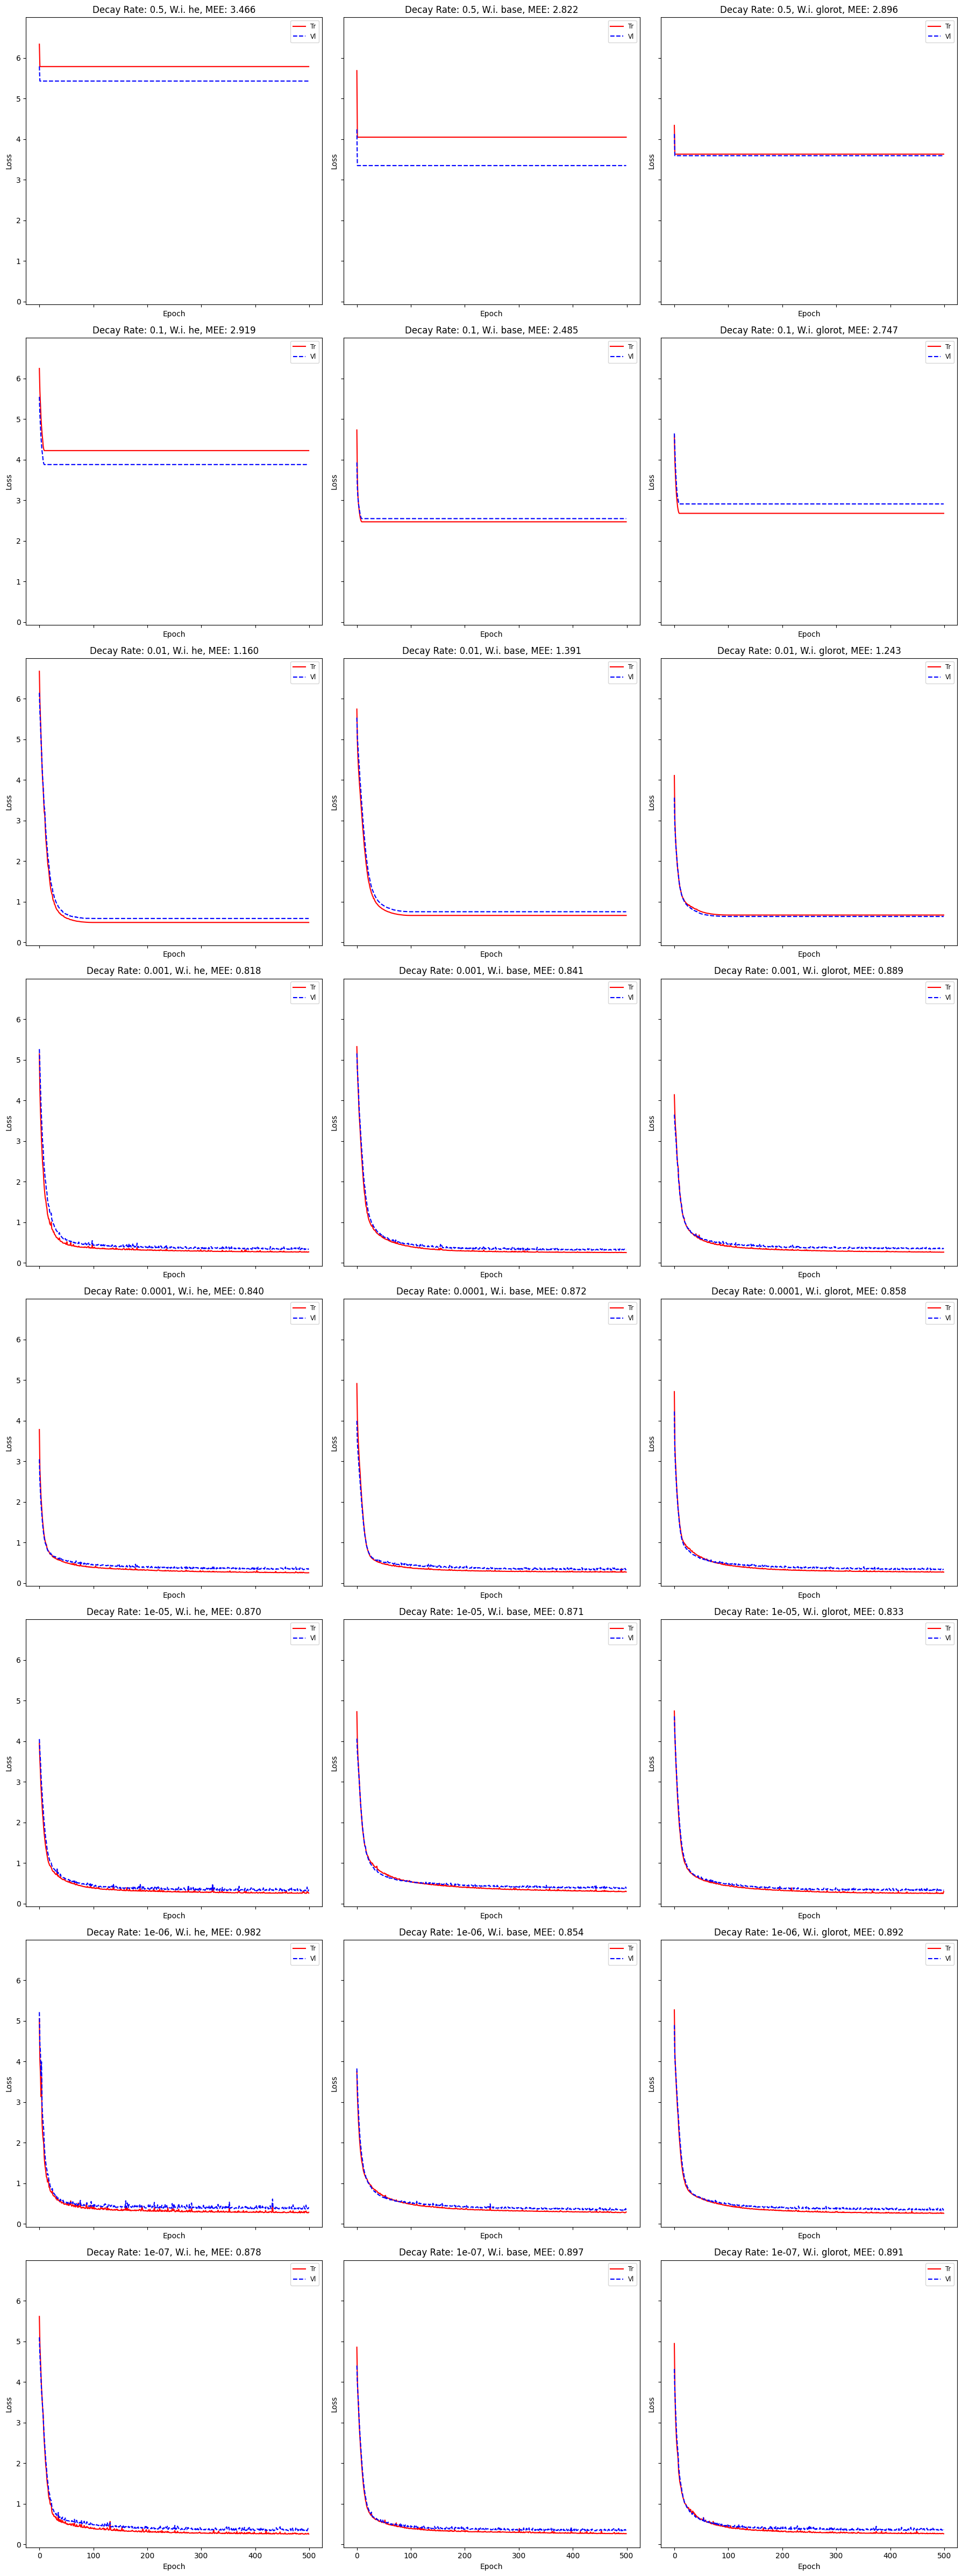

In [16]:
import matplotlib.pyplot as plt

decay_rates = [
    0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001
]

weight_init = [
   'he', 'base', 'glorot'
]

fig, axs = plt.subplots(len(decay_rates), len(weight_init), figsize=(6*len(weight_init), 6*len(decay_rates)),
                        sharex=True, sharey=True)

for i, dr in enumerate(decay_rates):
    for j, wi in enumerate(weight_init):
        nn = NeuralNetwork(
            layers=[12, 20, 3],
            learning_rate=0.001,
            decay_rate=dr, 
            lr_decay_type='linear', 
            error_function_name="mse",
            activation_function_names=["relu", "linear"],
            reg_type='l2',
            lambda_reg=.001,
            task="regression",
            weight_init=wi,
            momentum_type="none"
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=16,
            verbose=False,
            validation_data=(X_val_split, y_val_split),
        )
        
        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
        ax.set_title(f"Decay Rate: {dr}, W.i. {wi}, MEE: {mee:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

In [17]:
decay_rates = [
    0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001
]

weight_inits = [
   'he', 'base', 'glorot'
]

from tqdm import tqdm
SIMULATIONS = 10
results = []

for _ in tqdm(range(SIMULATIONS)):
    
    data = {}
    
    for i, dr in enumerate(decay_rates):
        for j, wi in enumerate(weight_inits):
            nn = NeuralNetwork(
                layers=[12, 20, 3],
                decay_rate=dr,
                learning_rate=0.001,
                lr_decay_type='linear', 
                error_function_name="mse",
                activation_function_names=["relu", "linear"],
                reg_type='l2',
                lambda_reg=.001,
                task="regression",
                weight_init=wi,
                momentum_type="none"
            )

            nn.train(
                X_train_split,
                y_train_split,
                epochs=500,
                batch_size=16,
                verbose=False,
                validation_data=(X_val_split, y_val_split),
            )
            
            mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
            data[(wi, dr)] = mee
            
    results.append(data)

100%|██████████| 10/10 [00:56<00:00,  5.63s/it]


In [18]:
1e-6, 1e-06

(1e-06, 1e-06)

In [19]:
reverse_index = {}
for data in results:
    for k in data:
        if k not in reverse_index:
            reverse_index[k] = []
        reverse_index[k].append(data[k])
        
for k in reverse_index:
    reverse_index[k] = {
        'mean' : np.mean(reverse_index[k]), 
        'std' : np.std(reverse_index[k])
    }
    
sorted_mean = sorted(reverse_index.items(), key=lambda x: x[1]['mean'])
sorted_std = sorted(reverse_index.items(), key=lambda x: x[1]['std'])

scores = []

for idx, el in enumerate(sorted_mean):
    index_in_std = sorted_std.index(el)
    scores.append((el, idx + index_in_std, el[1]['mean'], el[1]['std']))
    
sorted(scores, key=lambda x: x[1]) # glorot, 1e-06

[((('base', 0.0001),
   {'mean': np.float64(0.8768579877153068),
    'std': np.float64(0.020444747347234803)}),
  6,
  np.float64(0.8768579877153068),
  np.float64(0.020444747347234803)),
 ((('glorot', 1e-06),
   {'mean': np.float64(0.867880437343989),
    'std': np.float64(0.031180674586738778)}),
  8,
  np.float64(0.867880437343989),
  np.float64(0.031180674586738778)),
 ((('he', 1e-05),
   {'mean': np.float64(0.8706265805511479),
    'std': np.float64(0.027776309505492633)}),
  8,
  np.float64(0.8706265805511479),
  np.float64(0.027776309505492633)),
 ((('base', 1e-07),
   {'mean': np.float64(0.8797314735833064),
    'std': np.float64(0.023782203384015398)}),
  8,
  np.float64(0.8797314735833064),
  np.float64(0.023782203384015398)),
 ((('glorot', 0.0001),
   {'mean': np.float64(0.866716063523671),
    'std': np.float64(0.03504259719249685)}),
  9,
  np.float64(0.866716063523671),
  np.float64(0.03504259719249685)),
 ((('base', 1e-06),
   {'mean': np.float64(0.8753312588020128),
   

np.float64(0.8673397231740042)

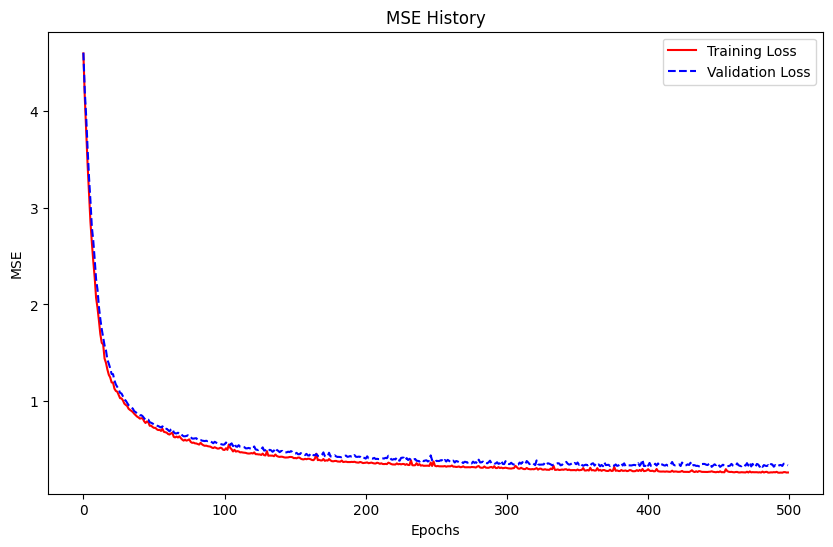

In [20]:
import matplotlib.pyplot as plt

nn = NeuralNetwork(
    layers=[12, 20, 3],
    learning_rate=0.001,
    decay_rate=1e-06,
    lr_decay_type="linear",
    error_function_name="mse",
    activation_function_names=["relu", "linear"],
    reg_type="l2",
    lambda_reg=0.001,
    task="regression",
    weight_init="glorot",
    momentum_type="none",
)

nn.train(
    X_train_split,
    y_train_split,
    epochs=500,
    batch_size=16,
    verbose=False,
    validation_data=(X_val_split, y_val_split),
)

nn.plot_learning_curve()
mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
mee

# So, till now I explored:
- Batch size vs Learning rate
- #Hidden layers vs Learning rate
- Decay type vs Decay rate vs Learning rate
- Weight init vs decay rate

**Let's now look at the momentum [type and alphas]**

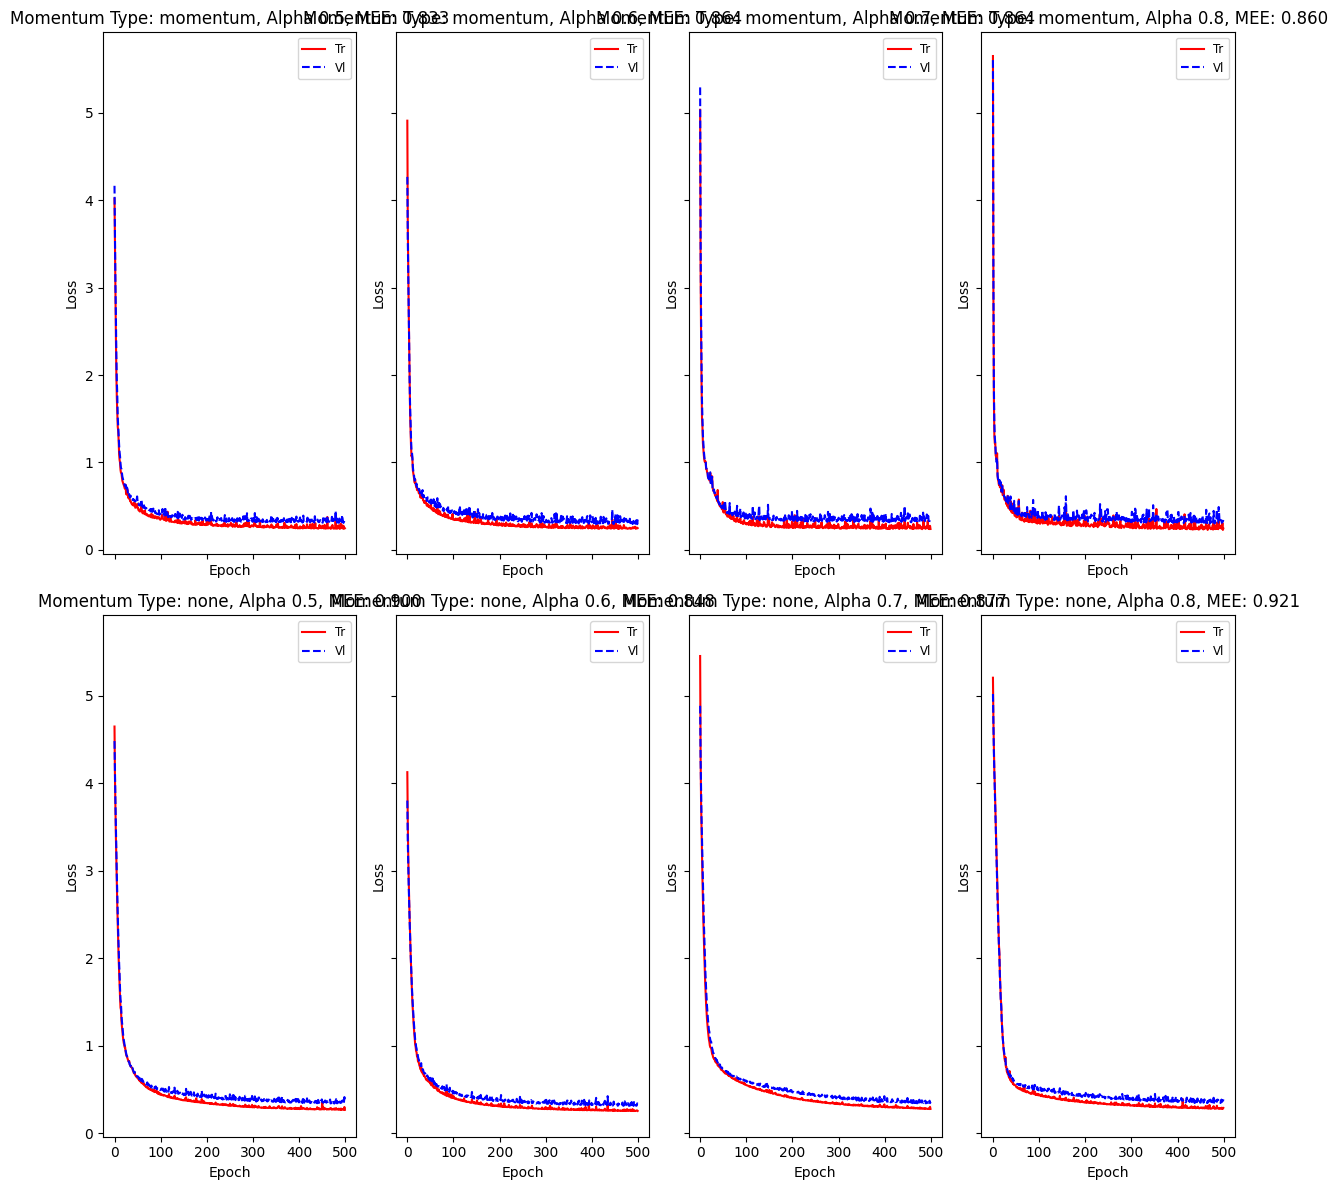

In [21]:
import matplotlib.pyplot as plt

momentum_alphas = [
    0.5, 0.6, 0.7, 0.8
]

momentum_types = [
   'momentum', 'none'
]

fig, axs = plt.subplots(len(momentum_types), len(momentum_alphas), figsize=(6*len(momentum_types), 6*len(momentum_types)),
                        sharex=True, sharey=True)

for i, mtype in enumerate(momentum_types):
    for j, alpha in enumerate(momentum_alphas):
        nn = NeuralNetwork(
            layers=[12, 20, 3],
            learning_rate=0.001,
            decay_rate=1e-6, 
            lr_decay_type='linear', 
            error_function_name="mse",
            activation_function_names=["relu", "linear"],
            reg_type='l2',
            lambda_reg=.001,
            task="regression",
            weight_init='glorot',
            momentum_alpha=alpha, 
            momentum_type=mtype
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=16,
            verbose=False,
            validation_data=(X_val_split, y_val_split),
        )
        
        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
        ax.set_title(f"Momentum Type: {mtype}, Alpha {alpha}, MEE: {mee:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

In [22]:
momentum_alphas = [
    0.5, 0.6, 0.7, 0.8
]

momentum_types = [
   'momentum', 'none'
]

from tqdm import tqdm
SIMULATIONS = 100
results = []

for _ in tqdm(range(SIMULATIONS)):
    
    data = {}
    
    for i, al in enumerate(momentum_alphas):
        for j, mt in enumerate(momentum_types):
            
            if mt == 'none' and al != 0:
                continue
            
            nn = NeuralNetwork(
                layers=[12, 20, 3],
                decay_rate=1e-6,
                learning_rate=0.001,
                lr_decay_type='linear', 
                error_function_name="mse",
                activation_function_names=["relu", "linear"],
                reg_type='l2',
                lambda_reg=.001,
                task="regression",
                weight_init='glorot',
                momentum_type=mt,
                momentum_alpha=al
            )

            nn.train(
                X_train_split,
                y_train_split,
                epochs=500,
                batch_size=16,
                verbose=False,
                validation_data=(X_val_split, y_val_split),
            )
            
            mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
            data[(al, mt)] = mee
            
    results.append(data)

100%|██████████| 100/100 [01:45<00:00,  1.05s/it]


In [23]:
reverse_index = {}
for data in results:
    for k in data:
        if k not in reverse_index:
            reverse_index[k] = []
        reverse_index[k].append(data[k])
        
for k in reverse_index:
    reverse_index[k] = {
        'mean' : np.mean(reverse_index[k]), 
        'std' : np.std(reverse_index[k])
    }
    
sorted_mean = sorted(reverse_index.items(), key=lambda x: x[1]['mean'])
sorted_std = sorted(reverse_index.items(), key=lambda x: x[1]['std'])

scores = []

for idx, el in enumerate(sorted_mean):
    index_in_std = sorted_std.index(el)
    scores.append((el, idx + index_in_std, el[1]['mean'], el[1]['std']))
    
sorted(scores, key=lambda x: x[1]) # glorot, 1e-06

[(((0.5, 'momentum'),
   {'mean': np.float64(0.863500742269047),
    'std': np.float64(0.0449886482155675)}),
  0,
  np.float64(0.863500742269047),
  np.float64(0.0449886482155675)),
 (((0.8, 'momentum'),
   {'mean': np.float64(0.8648521291357677),
    'std': np.float64(0.047819188012880244)}),
  3,
  np.float64(0.8648521291357677),
  np.float64(0.047819188012880244)),
 (((0.6, 'momentum'),
   {'mean': np.float64(0.8712851987955633),
    'std': np.float64(0.04714624871233891)}),
  3,
  np.float64(0.8712851987955633),
  np.float64(0.04714624871233891)),
 (((0.7, 'momentum'),
   {'mean': np.float64(0.8729014379815),
    'std': np.float64(0.05887789948659534)}),
  6,
  np.float64(0.8729014379815),
  np.float64(0.05887789948659534))]

after 100 simulations, we can see that alpha = 0.8 with "momentum" type is the best choice. We can see how it interacts with the learning rate.

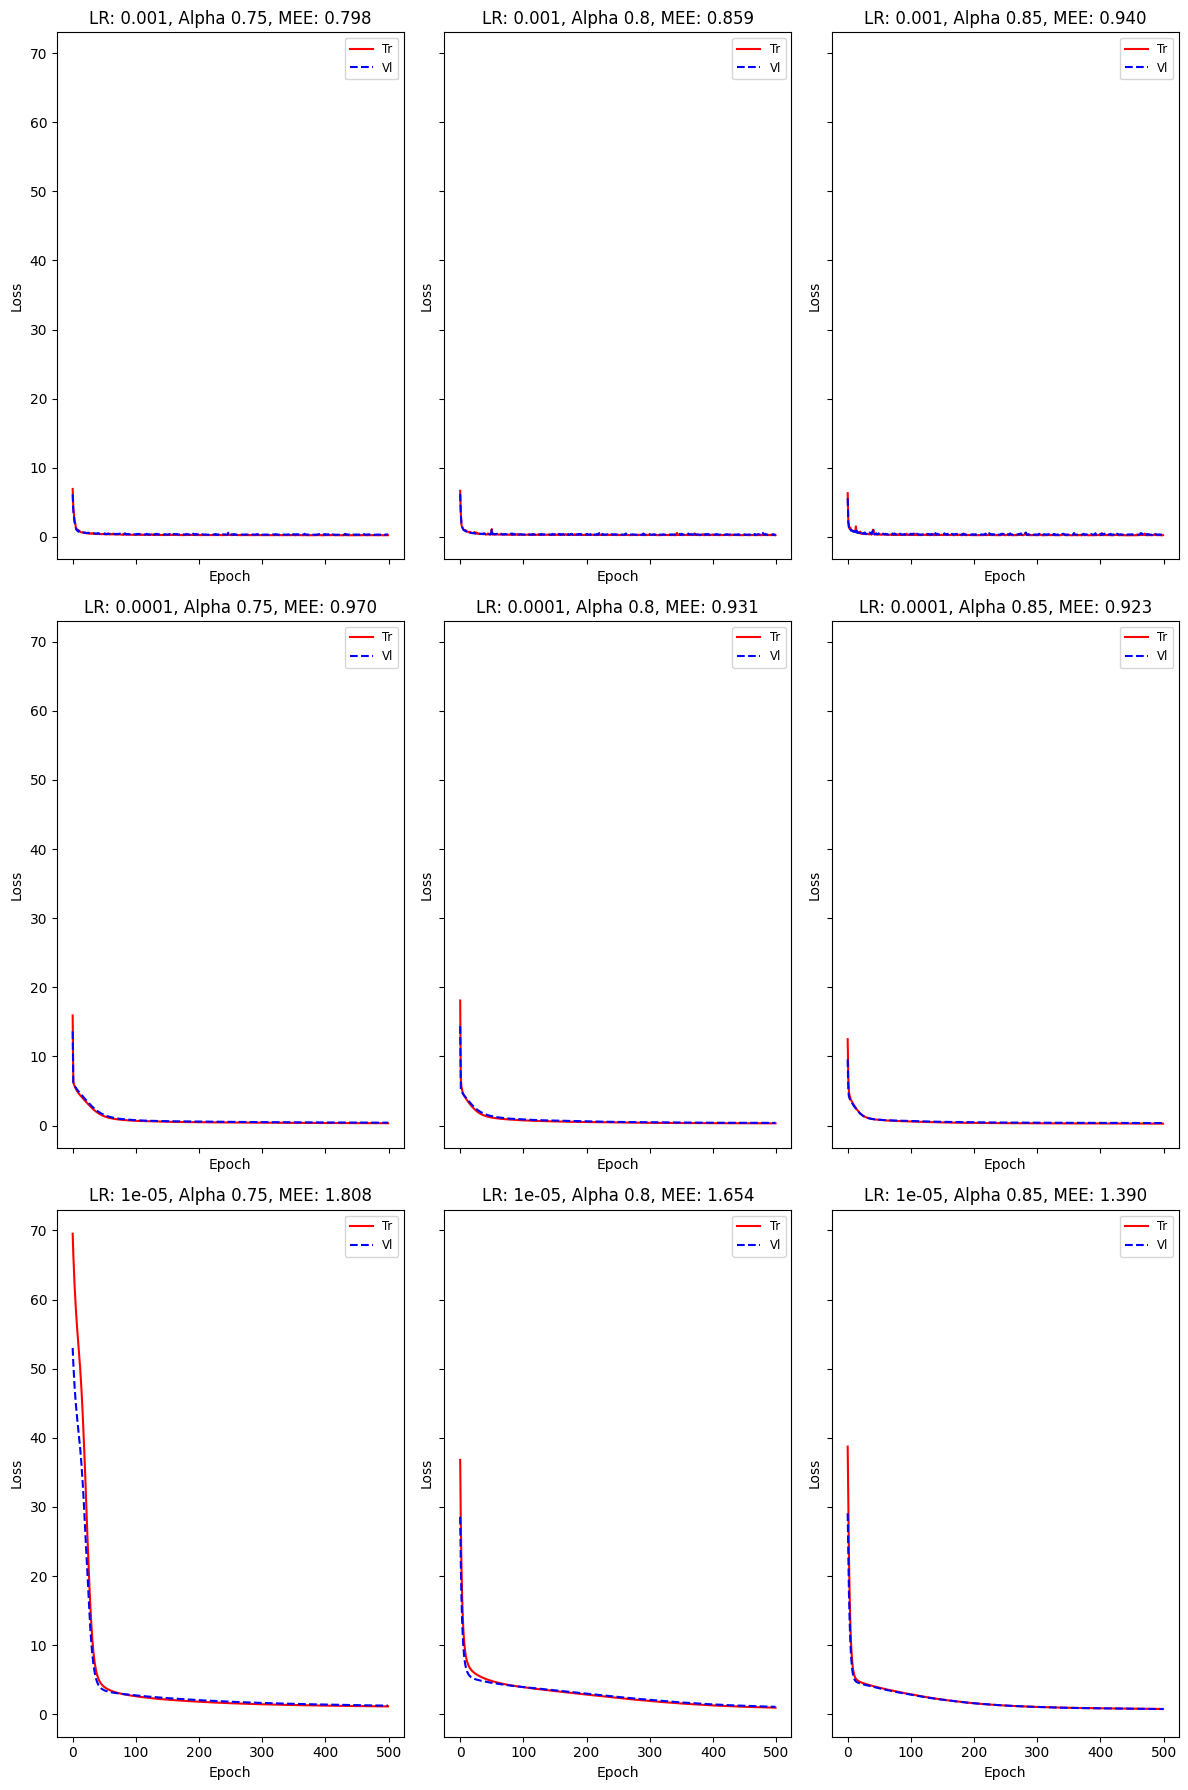

In [24]:
momentum_alphas = [
    0.75, 0.8, 0.85
]

lrs = [
    0.001, 0.0001, 0.00001    
]

fig, axs = plt.subplots(len(lrs), len(momentum_alphas), figsize=(6*len(momentum_types), 6*len(lrs)),
                        sharex=True, sharey=True)

for i, lr in enumerate(lrs):
    for j, alpha in enumerate(momentum_alphas):
        nn = NeuralNetwork(
            layers=[12, 20, 3],
            learning_rate=lr,
            decay_rate=1e-6, 
            lr_decay_type='linear', 
            error_function_name="mse",
            activation_function_names=["relu", "linear"],
            reg_type='l2',
            lambda_reg=.001,
            task="regression",
            weight_init='glorot',
            momentum_alpha=alpha, 
            momentum_type='momentum'
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=16,
            verbose=False,
            validation_data=(X_val_split, y_val_split),
        )
        
        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
        ax.set_title(f"LR: {lr}, Alpha {alpha}, MEE: {mee:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

In [25]:
momentum_alphas = [
    0.75, 0.8, 0.85
]

momentum_type = [
    'momentum', 'none'
]

lrs = [
    0.001, 0.0001, 0.00001    
]

from tqdm import tqdm
SIMULATIONS = 50
results = []

for _ in tqdm(range(SIMULATIONS)):
    
    data = {}
    
    for x, mt in enumerate(momentum_type):
        for i, al in enumerate(momentum_alphas):
            for j, lr in enumerate(lrs):
                
                if mt == 'none' and al != 0:
                    continue
                
                nn = NeuralNetwork(
                    layers=[12, 20, 3],
                    decay_rate=1e-6,
                    learning_rate=lr,
                    lr_decay_type='linear', 
                    error_function_name="mse",
                    activation_function_names=["relu", "linear"],
                    reg_type='l2',
                    lambda_reg=.001,
                    task="regression",
                    weight_init='glorot',
                    momentum_type=mt,
                    momentum_alpha=al
                )

                nn.train(
                    X_train_split,
                    y_train_split,
                    epochs=500,
                    batch_size=16,
                    verbose=False,
                    validation_data=(X_val_split, y_val_split),
                )
                
                mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
                data[(al, lr, mt)] = mee
                
    results.append(data)

100%|██████████| 50/50 [01:57<00:00,  2.35s/it]


In [26]:
reverse_index = {}
for data in results:
    for k in data:
        if k not in reverse_index:
            reverse_index[k] = []
        reverse_index[k].append(data[k])
        
for k in reverse_index:
    reverse_index[k] = {
        'mean' : np.mean(reverse_index[k]), 
        'std' : np.std(reverse_index[k])
    }
    
sorted_mean = sorted(reverse_index.items(), key=lambda x: x[1]['mean'])
sorted_std = sorted(reverse_index.items(), key=lambda x: x[1]['std'])

scores = []

for idx, el in enumerate(sorted_mean):
    index_in_std = sorted_std.index(el)
    scores.append((el, idx + index_in_std, el[1]['mean'], el[1]['std']))
    
sorted(scores, key=lambda x: x[1])

[(((0.75, 0.001, 'momentum'),
   {'mean': np.float64(0.8555027809254452),
    'std': np.float64(0.04667309610620259)}),
  2,
  np.float64(0.8555027809254452),
  np.float64(0.04667309610620259)),
 (((0.85, 0.0001, 'momentum'),
   {'mean': np.float64(0.8937685522552445),
    'std': np.float64(0.03159968346000768)}),
  3,
  np.float64(0.8937685522552445),
  np.float64(0.03159968346000768)),
 (((0.8, 0.001, 'momentum'),
   {'mean': np.float64(0.8583727147480447),
    'std': np.float64(0.05435326362026153)}),
  4,
  np.float64(0.8583727147480447),
  np.float64(0.05435326362026153)),
 (((0.8, 0.0001, 'momentum'),
   {'mean': np.float64(0.9282712158414057),
    'std': np.float64(0.038936584617554566)}),
  5,
  np.float64(0.9282712158414057),
  np.float64(0.038936584617554566)),
 (((0.85, 0.001, 'momentum'),
   {'mean': np.float64(0.8792324434548755),
    'std': np.float64(0.08333973023816037)}),
  7,
  np.float64(0.8792324434548755),
  np.float64(0.08333973023816037)),
 (((0.75, 0.0001, 'mome

np.float64(0.8553027921979026)

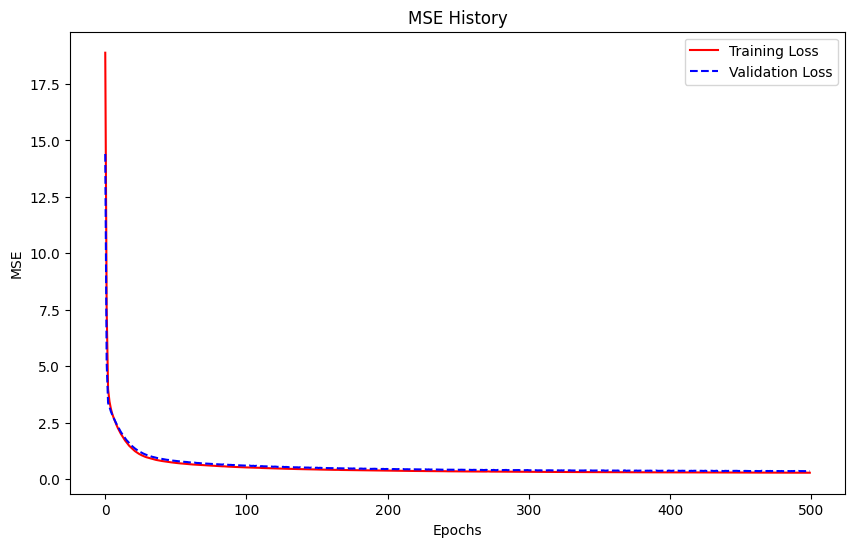

In [27]:
import matplotlib.pyplot as plt

nn = NeuralNetwork(
    layers=[12, 20, 3],
    learning_rate=0.0001,
    decay_rate=1e-06,
    lr_decay_type="linear",
    error_function_name="mse",
    activation_function_names=["relu", "linear"],
    reg_type="l2",
    lambda_reg=0.001,
    task="regression",
    weight_init="glorot",
    momentum_type="momentum",
    momentum_alpha=0.85
)

nn.train(
    X_train_split,
    y_train_split,
    epochs=500,
    batch_size=16,
    verbose=False,
    validation_data=(X_val_split, y_val_split),
)

nn.plot_learning_curve()
mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
mee

# Till now, our interesting model is:
```
    layers=[12, 20, 3],
    learning_rate=0.0001,
    decay_rate=1e-06,
    lr_decay_type="linear",
    error_function_name="mse",
    activation_function_names=["relu", "linear"],
    reg_type="l2",
    lambda_reg=0.001,
    task="regression",
    weight_init="glorot",
    momentum_type="momentum",
    momentum_alpha=0.85
```

**Let's see how the momentum interacts with the decay_rate**

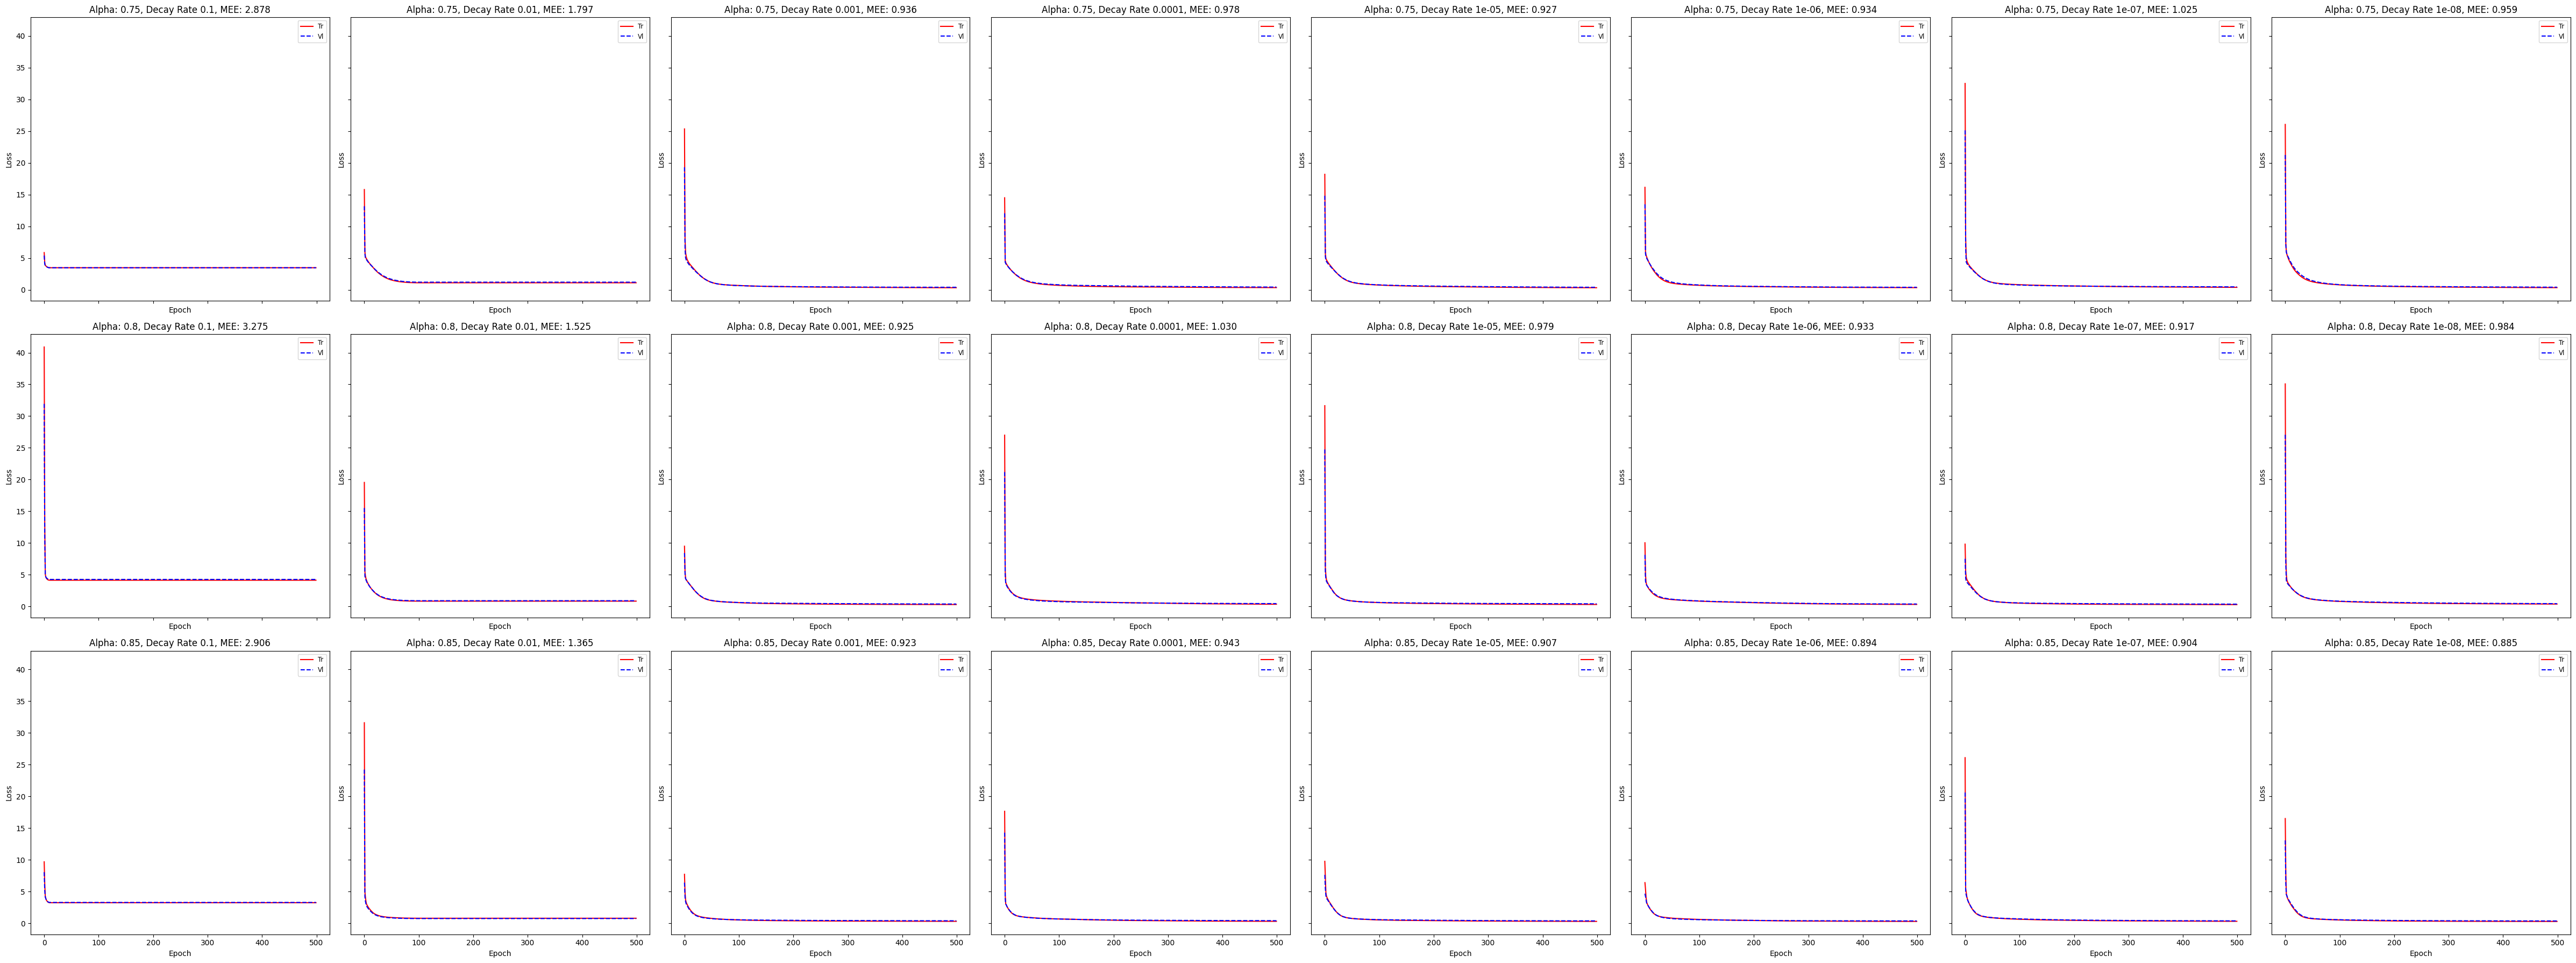

In [28]:
momentum_alphas = [
    0.75, 0.8, 0.85
]

decay_rates = [
    0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001, 0.00000001
]

fig, axs = plt.subplots(len(momentum_alphas), len(decay_rates), figsize=(6*len(decay_rates), 6*len(momentum_alphas)),
                        sharex=True, sharey=True)

for i, alpha in enumerate(momentum_alphas):
    for j, dr in enumerate(decay_rates):
        
        nn = NeuralNetwork(
            layers=[12, 20, 3],
            learning_rate=0.0001,
            decay_rate=dr, 
            lr_decay_type='linear', 
            error_function_name="mse",
            activation_function_names=["relu", "linear"],
            reg_type="l2",
            lambda_reg=0.001,
            task="regression",
            weight_init='glorot',
            momentum_alpha=alpha, 
            momentum_type='momentum'
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=16,
            verbose=False,
            validation_data=(X_val_split, y_val_split),
        )
        
        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
        ax.set_title(f"Alpha: {alpha}, Decay Rate {dr}, MEE: {mee:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

In [29]:
momentum_alphas = [0.75, 0.8, 0.85]

decay_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001, 0.00000001]

from tqdm import tqdm

SIMULATIONS = 100
results = []

for _ in tqdm(range(SIMULATIONS)):

    data = {}

    for x, alpha in enumerate(momentum_alphas):
        for j, dr in enumerate(decay_rates):

            nn = NeuralNetwork(
                layers=[12, 20, 3],
                decay_rate=dr,
                learning_rate=0.0001,
                lr_decay_type="linear",
                error_function_name="mse",
                activation_function_names=["relu", "linear"],
                reg_type="l2",
                lambda_reg=0.001,
                task="regression",
                weight_init="glorot",
                momentum_type='momentum',
                momentum_alpha=alpha,
            )

            nn.train(
                X_train_split,
                y_train_split,
                epochs=500,
                batch_size=16,
                verbose=False,
                validation_data=(X_val_split, y_val_split),
            )

            mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
            data[(dr, alpha)] = mee

    results.append(data)

100%|██████████| 100/100 [10:13<00:00,  6.14s/it]


In [30]:
reverse_index = {}
for data in results:
    for k in data:
        if k not in reverse_index:
            reverse_index[k] = []
        reverse_index[k].append(data[k])
        
for k in reverse_index:
    reverse_index[k] = {
        'mean' : np.mean(reverse_index[k]), 
        'std' : np.std(reverse_index[k])
    }
    
sorted_mean = sorted(reverse_index.items(), key=lambda x: x[1]['mean'])
sorted_std = sorted(reverse_index.items(), key=lambda x: x[1]['std'])

scores = []

for idx, el in enumerate(sorted_mean):
    index_in_std = sorted_std.index(el)
    scores.append((el, idx + index_in_std, el[1]['mean'], el[1]['std']))
    
sorted(scores, key=lambda x: x[1])

[(((1e-08, 0.85),
   {'mean': np.float64(0.8950898170857616),
    'std': np.float64(0.02626168555261145)}),
  0,
  np.float64(0.8950898170857616),
  np.float64(0.02626168555261145)),
 (((1e-05, 0.85),
   {'mean': np.float64(0.8973970603857859),
    'std': np.float64(0.02995957355502335)}),
  3,
  np.float64(0.8973970603857859),
  np.float64(0.02995957355502335)),
 (((1e-07, 0.85),
   {'mean': np.float64(0.8959622240946871),
    'std': np.float64(0.033690444037090525)}),
  6,
  np.float64(0.8959622240946871),
  np.float64(0.033690444037090525)),
 (((0.0001, 0.85),
   {'mean': np.float64(0.9011377879676984),
    'std': np.float64(0.031569426715224384)}),
  6,
  np.float64(0.9011377879676984),
  np.float64(0.031569426715224384)),
 (((1e-07, 0.8),
   {'mean': np.float64(0.9228906930183544),
    'std': np.float64(0.03298470362470507)}),
  8,
  np.float64(0.9228906930183544),
  np.float64(0.03298470362470507)),
 (((1e-06, 0.85),
   {'mean': np.float64(0.8999221572430731),
    'std': np.float

np.float64(0.9492169529071001)

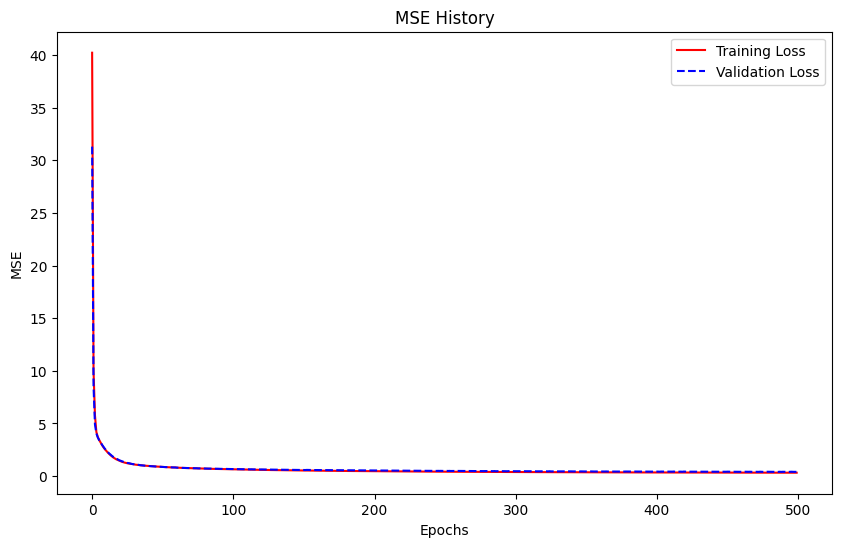

In [31]:
import matplotlib.pyplot as plt

nn = NeuralNetwork(
    layers=[12, 20, 3],
    learning_rate=0.0001,
    decay_rate=1e-08,
    lr_decay_type="linear",
    error_function_name="mse",
    activation_function_names=["relu", "linear"],
    reg_type="l2",
    lambda_reg=0.001,
    task="regression",
    weight_init="glorot",
    momentum_type="momentum",
    momentum_alpha=0.85
)

nn.train(
    X_train_split,
    y_train_split,
    epochs=500,
    batch_size=16,
    verbose=False,
    validation_data=(X_val_split, y_val_split),
)

nn.plot_learning_curve()
mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
mee

# At this point we can see how the regularization comes into play

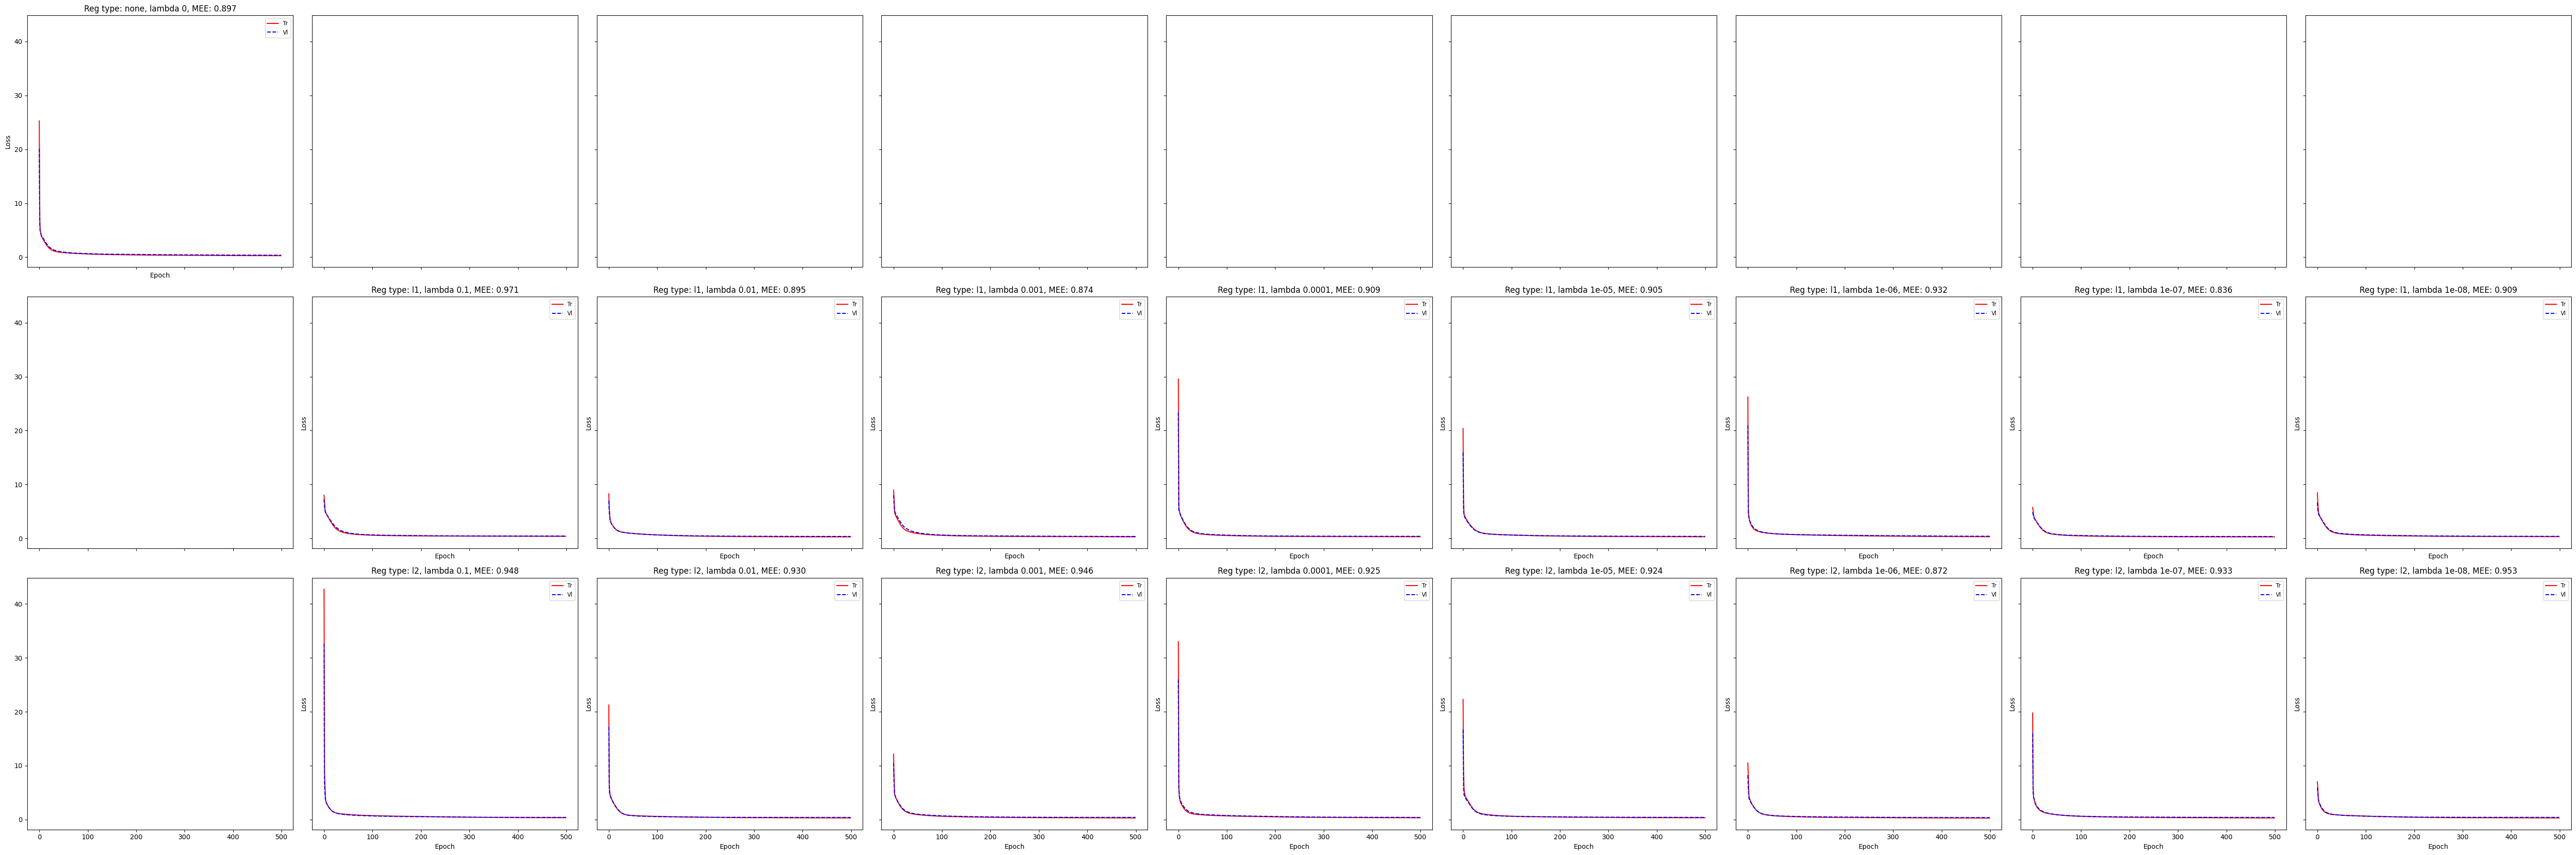

In [32]:
rtypes = [
 'none', 'l1', 'l2'
]

lambdas = [
    0, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001, 0.00000001
]

fig, axs = plt.subplots(len(rtypes), len(lambdas), figsize=(6*len(lambdas), 6*len(rtypes)),
                        sharex=True, sharey=True)

for i, rt in enumerate(rtypes):
    for j, lmb in enumerate(lambdas):
        
        if rt == 'none' and lmb != 0:
            continue
        
        if rt != 'none' and lmb == 0:
            continue
        
        nn = NeuralNetwork(
            layers=[12, 20, 3],
            learning_rate=0.0001,
            decay_rate=1e-8, 
            lr_decay_type='linear', 
            error_function_name="mse",
            activation_function_names=["relu", "linear"],
            reg_type=rt,
            lambda_reg=lmb,
            task="regression",
            weight_init='glorot',
            momentum_alpha=0.85, 
            momentum_type='momentum'
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=16,
            verbose=False,
            validation_data=(X_val_split, y_val_split),
        )
        
        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        mee = nn.evaluate(X_val_split, y_val_split, evaluation_function_name="mee")
        ax.set_title(f"Reg type: {rt}, lambda {lmb}, MEE: {mee:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()